# Classificação de Batimentos Cardíacos: Regressão Logística vs Rede Neuromórfica (LIF)

**Objetivo:** Comparar um classificador tradicional (Regressão Logística) com um modelo
neuromórfico simplificado (Leaky Integrate-and-Fire) na classificação de sinais ECG.

**Datasets:** MIT-BIH Arrhythmia Dataset e PTB Diagnostic ECG Database

## 1. Importações e Configuração

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import time
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Carregamento dos Dados

In [3]:
# MIT-BIH Arrhythmia Dataset
print("Carregando MIT-BIH dataset...")
mitbih_train = pd.read_csv('mitbih_train.csv', header=None)
mitbih_test = pd.read_csv('mitbih_test.csv', header=None)

print(f"MIT-BIH Train: {mitbih_train.shape}")
print(f"MIT-BIH Test: {mitbih_test.shape}")

# PTB Diagnostic ECG Database
print("\nCarregando PTB dataset...")
ptbdb_normal = pd.read_csv('ptbdb_normal.csv', header=None)
ptbdb_abnormal = pd.read_csv('ptbdb_abnormal.csv', header=None)

print(f"PTB Normal: {ptbdb_normal.shape}")
print(f"PTB Abnormal: {ptbdb_abnormal.shape}")

Carregando MIT-BIH dataset...
MIT-BIH Train: (87554, 188)
MIT-BIH Test: (21892, 188)

Carregando PTB dataset...
PTB Normal: (4046, 188)
PTB Abnormal: (10506, 188)


## 3. Preparação dos Dados

In [4]:
# --- MIT-BIH: Separar features e labels ---
X_train_mitbih = mitbih_train.iloc[:, :-1].values
y_train_mitbih = mitbih_train.iloc[:, -1].values.astype(int)
X_test_mitbih = mitbih_test.iloc[:, :-1].values
y_test_mitbih = mitbih_test.iloc[:, -1].values.astype(int)

print("MIT-BIH - Distribuição de classes (treino):")
unique, counts = np.unique(y_train_mitbih, return_counts=True)
classes_mitbih = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)', 'F (Fusão)', 'Q (Desconhecido)']
for c, n in zip(unique, counts):
    print(f"  Classe {c} ({classes_mitbih[c]}): {n} ({100*n/len(y_train_mitbih):.1f}%)")

# --- PTB: Combinar e separar ---
ptb_data = pd.concat([ptbdb_normal, ptbdb_abnormal], ignore_index=True)
X_ptb = ptb_data.iloc[:, :-1].values
y_ptb = ptb_data.iloc[:, -1].values.astype(int)

X_train_ptb, X_test_ptb, y_train_ptb, y_test_ptb = train_test_split(
    X_ptb, y_ptb, test_size=0.2, random_state=42, stratify=y_ptb
)

print(f"\nPTB - Train: {X_train_ptb.shape}, Test: {X_test_ptb.shape}")
print(f"PTB - Classes: 0=Normal ({(y_ptb==0).sum()}), 1=Anormal ({(y_ptb==1).sum()})")

MIT-BIH - Distribuição de classes (treino):
  Classe 0 (N (Normal)): 72471 (82.8%)
  Classe 1 (S (Supraventricular)): 2223 (2.5%)
  Classe 2 (V (Ventricular)): 5788 (6.6%)
  Classe 3 (F (Fusão)): 641 (0.7%)
  Classe 4 (Q (Desconhecido)): 6431 (7.3%)

PTB - Train: (11641, 187), Test: (2911, 187)
PTB - Classes: 0=Normal (4046), 1=Anormal (10506)


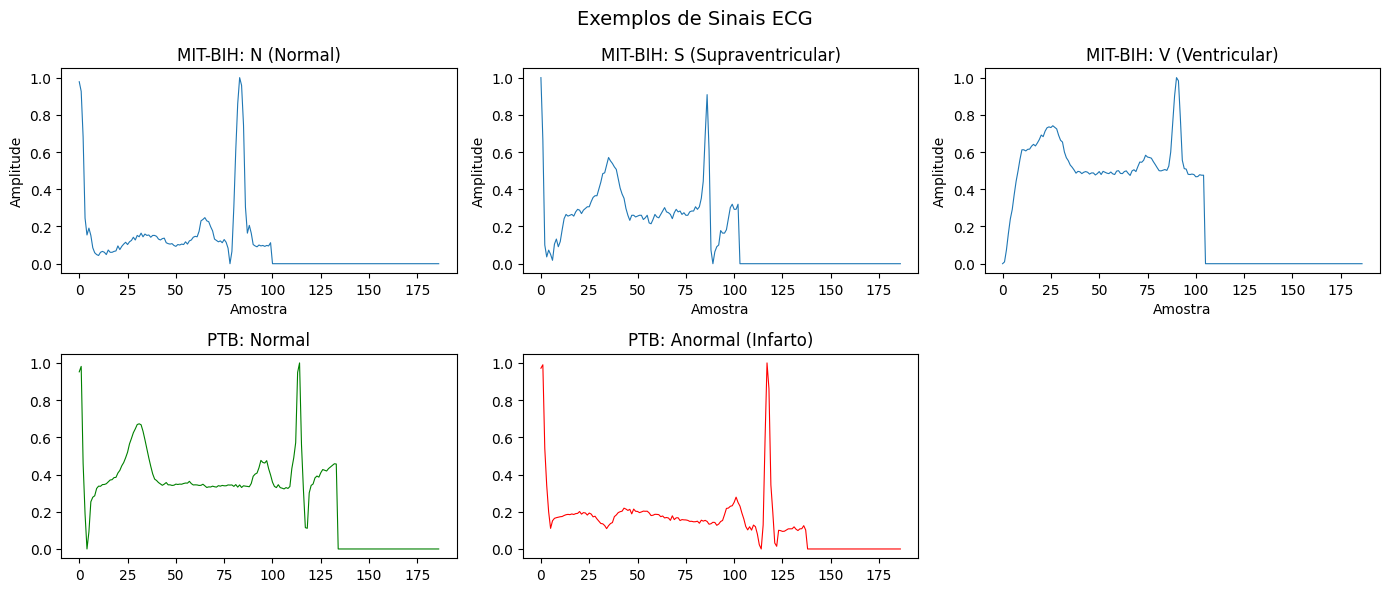

Figura salva: ecg_exemplos.png


In [5]:
# Visualização de exemplos de sinais ECG
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle('Exemplos de Sinais ECG', fontsize=14)

# MIT-BIH
for i, cls in enumerate([0, 1, 2]):
    idx = np.where(y_train_mitbih == cls)[0][0]
    axes[0, i].plot(X_train_mitbih[idx], linewidth=0.8)
    axes[0, i].set_title(f'MIT-BIH: {classes_mitbih[cls]}')
    axes[0, i].set_xlabel('Amostra')
    axes[0, i].set_ylabel('Amplitude')

# PTB
idx_normal = np.where(y_train_ptb == 0)[0][0]
idx_abnormal = np.where(y_train_ptb == 1)[0][0]
axes[1, 0].plot(X_train_ptb[idx_normal], linewidth=0.8, color='green')
axes[1, 0].set_title('PTB: Normal')
axes[1, 1].plot(X_train_ptb[idx_abnormal], linewidth=0.8, color='red')
axes[1, 1].set_title('PTB: Anormal (Infarto)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('ecg_exemplos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: ecg_exemplos.png")

## 4. Modelo 1: Regressão Logística (Classificador Tradicional)

In [6]:
# Normalização
scaler_mitbih = StandardScaler()
X_train_mitbih_scaled = scaler_mitbih.fit_transform(X_train_mitbih)
X_test_mitbih_scaled = scaler_mitbih.transform(X_test_mitbih)

scaler_ptb = StandardScaler()
X_train_ptb_scaled = scaler_ptb.fit_transform(X_train_ptb)
X_test_ptb_scaled = scaler_ptb.transform(X_test_ptb)

# --- Regressão Logística no MIT-BIH ---
print("=" * 60)
print("REGRESSÃO LOGÍSTICA - MIT-BIH (5 classes)")
print("=" * 60)

start_time = time.time()
lr_mitbih = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_mitbih.fit(X_train_mitbih_scaled, y_train_mitbih)
lr_mitbih_train_time = time.time() - start_time

start_time = time.time()
y_pred_lr_mitbih = lr_mitbih.predict(X_test_mitbih_scaled)
lr_mitbih_pred_time = time.time() - start_time

acc_lr_mitbih = accuracy_score(y_test_mitbih, y_pred_lr_mitbih)
f1_lr_mitbih = f1_score(y_test_mitbih, y_pred_lr_mitbih, average='weighted')

print(f"Acurácia: {acc_lr_mitbih:.4f}")
print(f"F1-Score (weighted): {f1_lr_mitbih:.4f}")
print(f"Tempo de treino: {lr_mitbih_train_time:.2f}s")
print(f"Tempo de inferência: {lr_mitbih_pred_time:.4f}s")
print("\nRelatório de Classificação:")
print(classification_report(y_test_mitbih, y_pred_lr_mitbih, target_names=classes_mitbih))

REGRESSÃO LOGÍSTICA - MIT-BIH (5 classes)
Acurácia: 0.9147
F1-Score (weighted): 0.9030
Tempo de treino: 11.04s
Tempo de inferência: 0.0046s

Relatório de Classificação:
                      precision    recall  f1-score   support

          N (Normal)       0.92      0.98      0.95     18118
S (Supraventricular)       0.82      0.41      0.55       556
     V (Ventricular)       0.66      0.33      0.44      1448
           F (Fusão)       0.58      0.37      0.45       162
    Q (Desconhecido)       0.96      0.88      0.92      1608

            accuracy                           0.91     21892
           macro avg       0.79      0.60      0.66     21892
        weighted avg       0.90      0.91      0.90     21892



In [7]:
# --- Regressão Logística no PTB ---
print("=" * 60)
print("REGRESSÃO LOGÍSTICA - PTB (binário: Normal vs Anormal)")
print("=" * 60)

start_time = time.time()
lr_ptb = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_ptb.fit(X_train_ptb_scaled, y_train_ptb)
lr_ptb_train_time = time.time() - start_time

start_time = time.time()
y_pred_lr_ptb = lr_ptb.predict(X_test_ptb_scaled)
lr_ptb_pred_time = time.time() - start_time

acc_lr_ptb = accuracy_score(y_test_ptb, y_pred_lr_ptb)
f1_lr_ptb = f1_score(y_test_ptb, y_pred_lr_ptb, average='weighted')
y_prob_lr_ptb = lr_ptb.predict_proba(X_test_ptb_scaled)[:, 1]
auc_lr_ptb = roc_auc_score(y_test_ptb, y_prob_lr_ptb)

print(f"Acurácia: {acc_lr_ptb:.4f}")
print(f"F1-Score (weighted): {f1_lr_ptb:.4f}")
print(f"AUC-ROC: {auc_lr_ptb:.4f}")
print(f"Tempo de treino: {lr_ptb_train_time:.2f}s")
print(f"Tempo de inferência: {lr_ptb_pred_time:.4f}s")
print("\nRelatório de Classificação:")
print(classification_report(y_test_ptb, y_pred_lr_ptb, target_names=['Normal', 'Anormal']))

REGRESSÃO LOGÍSTICA - PTB (binário: Normal vs Anormal)
Acurácia: 0.8286
F1-Score (weighted): 0.8203
AUC-ROC: 0.8694
Tempo de treino: 0.24s
Tempo de inferência: 0.0013s

Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       0.75      0.57      0.65       809
     Anormal       0.85      0.93      0.89      2102

    accuracy                           0.83      2911
   macro avg       0.80      0.75      0.77      2911
weighted avg       0.82      0.83      0.82      2911



## 5. Modelo 2: Rede Neuromórfica - Leaky Integrate-and-Fire (LIF)

O modelo LIF simula neurônios biológicos que acumulam potencial de membrana ao longo
do tempo e disparam (spike) quando um limiar é atingido. Usamos a contagem de spikes
como features para classificação.

In [8]:
class LIFNeuron:
    """
    Neurônio Leaky Integrate-and-Fire (LIF).
    
    Parâmetros:
        tau_m: constante de tempo da membrana (ms)
        v_thresh: limiar de disparo
        v_reset: potencial de reset após disparo
        v_rest: potencial de repouso
        dt: passo temporal (ms)
    """
    def __init__(self, tau_m=20.0, v_thresh=1.0, v_reset=0.0, v_rest=0.0, dt=1.0):
        self.tau_m = tau_m
        self.v_thresh = v_thresh
        self.v_reset = v_reset
        self.v_rest = v_rest
        self.dt = dt
    
    def simulate(self, input_current):
        """
        Simula o neurônio LIF para uma corrente de entrada.
        
        Retorna:
            spike_times: índices temporais dos spikes
            membrane_potential: histórico do potencial de membrana
        """
        n_steps = len(input_current)
        v = np.zeros(n_steps)
        v[0] = self.v_rest
        spike_times = []
        
        for t in range(1, n_steps):
            # Equação diferencial do LIF (Euler)
            dv = (-(v[t-1] - self.v_rest) + input_current[t-1]) * (self.dt / self.tau_m)
            v[t] = v[t-1] + dv
            
            # Verificar disparo
            if v[t] >= self.v_thresh:
                spike_times.append(t)
                v[t] = self.v_reset
        
        return np.array(spike_times), v


class LIFEncoder:
    """
    Codificador neuromórfico: converte sinais ECG em padrões de spikes
    usando uma população de neurônios LIF com diferentes limiares.
    """
    def __init__(self, n_neurons=10, tau_range=(5, 50), thresh_range=(0.3, 1.5)):
        self.n_neurons = n_neurons
        # Criar população com parâmetros variados
        self.neurons = []
        taus = np.linspace(tau_range[0], tau_range[1], n_neurons)
        thresholds = np.linspace(thresh_range[0], thresh_range[1], n_neurons)
        
        for i in range(n_neurons):
            self.neurons.append(LIFNeuron(tau_m=taus[i], v_thresh=thresholds[i]))
    
    def encode(self, signal):
        """
        Codifica um sinal ECG em features baseadas em spikes.
        
        Features extraídas por neurônio:
            - Contagem total de spikes
            - Taxa média de disparo
            - Intervalo médio entre spikes (ISI)
            - Variância do ISI
        """
        features = []
        
        for neuron in self.neurons:
            spike_times, _ = neuron.simulate(signal)
            
            # Contagem de spikes
            spike_count = len(spike_times)
            features.append(spike_count)
            
            # Taxa de disparo
            firing_rate = spike_count / len(signal)
            features.append(firing_rate)
            
            # Intervalo entre spikes (ISI)
            if len(spike_times) > 1:
                isis = np.diff(spike_times)
                mean_isi = np.mean(isis)
                var_isi = np.var(isis)
            else:
                mean_isi = 0
                var_isi = 0
            features.append(mean_isi)
            features.append(var_isi)
        
        return np.array(features)
    
    def encode_dataset(self, X):
        """Codifica um dataset inteiro."""
        n_samples = X.shape[0]
        # 4 features por neurônio
        n_features = self.n_neurons * 4
        X_encoded = np.zeros((n_samples, n_features))
        
        for i in range(n_samples):
            X_encoded[i] = self.encode(X[i])
            if (i + 1) % 5000 == 0:
                print(f"  Codificados {i+1}/{n_samples} sinais...")
        
        return X_encoded

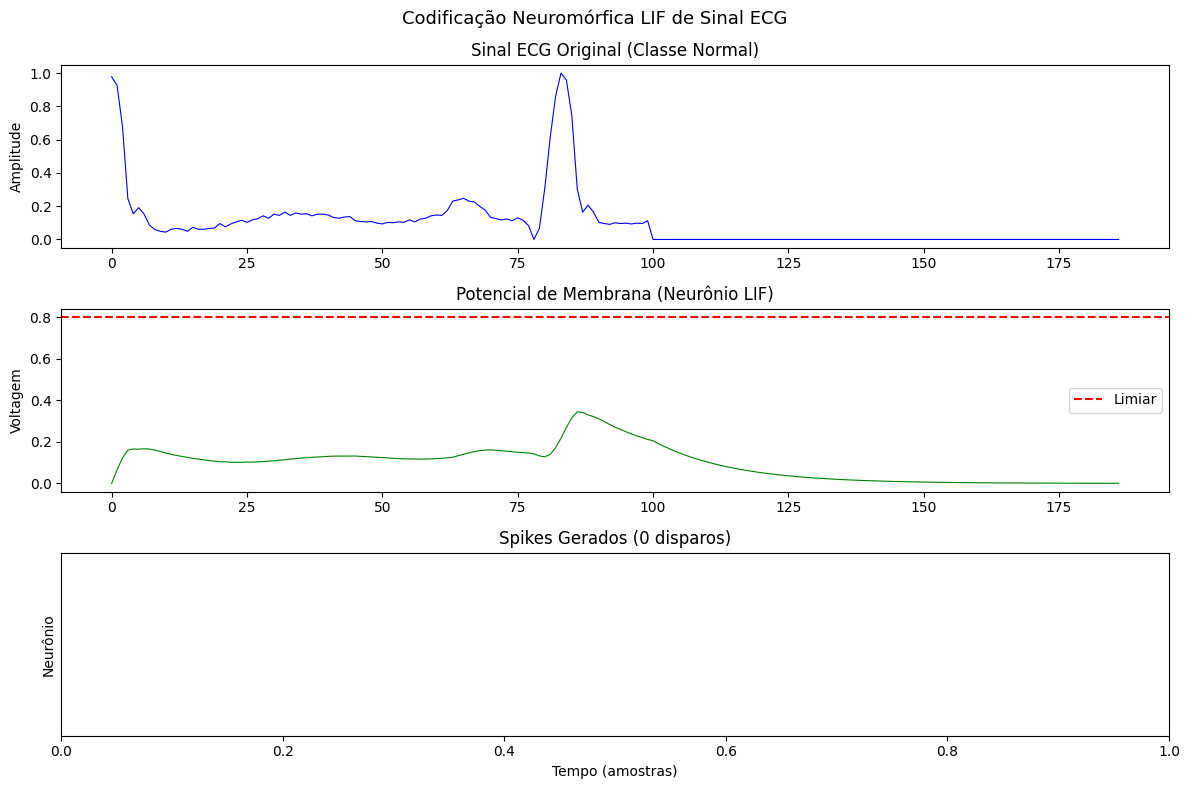

Figura salva: lif_encoding.png


In [9]:
# Visualização do processo de codificação LIF
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle('Codificação Neuromórfica LIF de Sinal ECG', fontsize=13)

# Sinal ECG original
sample_signal = X_train_mitbih[0]
axes[0].plot(sample_signal, 'b-', linewidth=0.8)
axes[0].set_title('Sinal ECG Original (Classe Normal)')
axes[0].set_ylabel('Amplitude')

# Potencial de membrana de um neurônio LIF
neuron = LIFNeuron(tau_m=15.0, v_thresh=0.8)
spikes, membrane = neuron.simulate(sample_signal)
axes[1].plot(membrane, 'g-', linewidth=0.8)
axes[1].axhline(y=0.8, color='r', linestyle='--', label='Limiar')
axes[1].set_title('Potencial de Membrana (Neurônio LIF)')
axes[1].set_ylabel('Voltagem')
axes[1].legend()

# Raster plot de spikes
axes[2].eventplot([spikes], lineoffsets=0, linelengths=0.8, colors='k')
axes[2].set_title(f'Spikes Gerados ({len(spikes)} disparos)')
axes[2].set_xlabel('Tempo (amostras)')
axes[2].set_ylabel('Neurônio')
axes[2].set_yticks([])

plt.tight_layout()
plt.savefig('lif_encoding.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: lif_encoding.png")

In [10]:
# --- Codificação LIF do dataset PTB (binário, mais rápido) ---
print("=" * 60)
print("REDE NEUROMÓRFICA LIF - Codificação dos Sinais")
print("=" * 60)

encoder = LIFEncoder(n_neurons=10, tau_range=(5, 40), thresh_range=(0.3, 1.2))

print("\nCodificando PTB Train...")
start_time = time.time()
X_train_ptb_lif = encoder.encode_dataset(X_train_ptb)
lif_ptb_encode_train_time = time.time() - start_time

print("Codificando PTB Test...")
X_test_ptb_lif = encoder.encode_dataset(X_test_ptb)

print(f"\nFeatures LIF geradas: {X_train_ptb_lif.shape[1]} (4 features x {encoder.n_neurons} neurônios)")
print(f"Tempo de codificação (treino): {lif_ptb_encode_train_time:.2f}s")

REDE NEUROMÓRFICA LIF - Codificação dos Sinais

Codificando PTB Train...
  Codificados 5000/11641 sinais...
  Codificados 10000/11641 sinais...
Codificando PTB Test...

Features LIF geradas: 40 (4 features x 10 neurônios)
Tempo de codificação (treino): 9.50s


In [11]:
# --- Codificação LIF do MIT-BIH (amostra para viabilidade computacional) ---
print("\nCodificando MIT-BIH (amostra de 20000 para treino)...")
np.random.seed(42)
sample_idx_train = np.random.choice(len(X_train_mitbih), size=20000, replace=False)
sample_idx_test = np.random.choice(len(X_test_mitbih), size=5000, replace=False)

X_train_mitbih_sample = X_train_mitbih[sample_idx_train]
y_train_mitbih_sample = y_train_mitbih[sample_idx_train]
X_test_mitbih_sample = X_test_mitbih[sample_idx_test]
y_test_mitbih_sample = y_test_mitbih[sample_idx_test]

start_time = time.time()
X_train_mitbih_lif = encoder.encode_dataset(X_train_mitbih_sample)
lif_mitbih_encode_time = time.time() - start_time

X_test_mitbih_lif = encoder.encode_dataset(X_test_mitbih_sample)

print(f"Tempo de codificação MIT-BIH (treino): {lif_mitbih_encode_time:.2f}s")


Codificando MIT-BIH (amostra de 20000 para treino)...
  Codificados 5000/20000 sinais...
  Codificados 10000/20000 sinais...
  Codificados 15000/20000 sinais...
  Codificados 20000/20000 sinais...
  Codificados 5000/5000 sinais...
Tempo de codificação MIT-BIH (treino): 16.57s


In [12]:
# --- Classificação com features LIF (usando Regressão Logística como readout) ---
print("\n" + "=" * 60)
print("REDE NEUROMÓRFICA LIF + READOUT - PTB")
print("=" * 60)

scaler_lif_ptb = StandardScaler()
X_train_ptb_lif_scaled = scaler_lif_ptb.fit_transform(X_train_ptb_lif)
X_test_ptb_lif_scaled = scaler_lif_ptb.transform(X_test_ptb_lif)

start_time = time.time()
lr_lif_ptb = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_lif_ptb.fit(X_train_ptb_lif_scaled, y_train_ptb)
lif_ptb_train_time = time.time() - start_time

start_time = time.time()
y_pred_lif_ptb = lr_lif_ptb.predict(X_test_ptb_lif_scaled)
lif_ptb_pred_time = time.time() - start_time

acc_lif_ptb = accuracy_score(y_test_ptb, y_pred_lif_ptb)
f1_lif_ptb = f1_score(y_test_ptb, y_pred_lif_ptb, average='weighted')
y_prob_lif_ptb = lr_lif_ptb.predict_proba(X_test_ptb_lif_scaled)[:, 1]
auc_lif_ptb = roc_auc_score(y_test_ptb, y_prob_lif_ptb)

print(f"Acurácia: {acc_lif_ptb:.4f}")
print(f"F1-Score (weighted): {f1_lif_ptb:.4f}")
print(f"AUC-ROC: {auc_lif_ptb:.4f}")
print(f"Tempo de treino (readout): {lif_ptb_train_time:.4f}s")
print(f"Tempo de inferência: {lif_ptb_pred_time:.4f}s")
print(f"Tempo total (encode + treino): {lif_ptb_encode_train_time + lif_ptb_train_time:.2f}s")
print("\nRelatório de Classificação:")
print(classification_report(y_test_ptb, y_pred_lif_ptb, target_names=['Normal', 'Anormal']))


REDE NEUROMÓRFICA LIF + READOUT - PTB
Acurácia: 0.7241
F1-Score (weighted): 0.6319
AUC-ROC: 0.7002
Tempo de treino (readout): 0.0131s
Tempo de inferência: 0.0003s
Tempo total (encode + treino): 9.51s

Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       0.54      0.05      0.10       809
     Anormal       0.73      0.98      0.84      2102

    accuracy                           0.72      2911
   macro avg       0.63      0.52      0.47      2911
weighted avg       0.68      0.72      0.63      2911



In [13]:
# --- LIF + Readout no MIT-BIH ---
print("=" * 60)
print("REDE NEUROMÓRFICA LIF + READOUT - MIT-BIH")
print("=" * 60)

scaler_lif_mitbih = StandardScaler()
X_train_mitbih_lif_scaled = scaler_lif_mitbih.fit_transform(X_train_mitbih_lif)
X_test_mitbih_lif_scaled = scaler_lif_mitbih.transform(X_test_mitbih_lif)

start_time = time.time()
lr_lif_mitbih = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_lif_mitbih.fit(X_train_mitbih_lif_scaled, y_train_mitbih_sample)
lif_mitbih_train_time = time.time() - start_time

y_pred_lif_mitbih = lr_lif_mitbih.predict(X_test_mitbih_lif_scaled)

acc_lif_mitbih = accuracy_score(y_test_mitbih_sample, y_pred_lif_mitbih)
f1_lif_mitbih = f1_score(y_test_mitbih_sample, y_pred_lif_mitbih, average='weighted')

print(f"Acurácia: {acc_lif_mitbih:.4f}")
print(f"F1-Score (weighted): {f1_lif_mitbih:.4f}")
print(f"Tempo de codificação + treino: {lif_mitbih_encode_time + lif_mitbih_train_time:.2f}s")
print("\nRelatório de Classificação:")
print(classification_report(y_test_mitbih_sample, y_pred_lif_mitbih, target_names=classes_mitbih))

REDE NEUROMÓRFICA LIF + READOUT - MIT-BIH
Acurácia: 0.8364
F1-Score (weighted): 0.7874
Tempo de codificação + treino: 16.74s

Relatório de Classificação:
                      precision    recall  f1-score   support

          N (Normal)       0.85      0.98      0.91      4154
S (Supraventricular)       1.00      0.01      0.02       126
     V (Ventricular)       0.60      0.13      0.21       328
           F (Fusão)       0.00      0.00      0.00        36
    Q (Desconhecido)       0.47      0.15      0.23       356

            accuracy                           0.84      5000
           macro avg       0.58      0.25      0.27      5000
        weighted avg       0.80      0.84      0.79      5000



## 6. Comparação dos Modelos

In [14]:
# Tabela comparativa
print("=" * 70)
print("COMPARAÇÃO FINAL DOS MODELOS")
print("=" * 70)

results = {
    'Dataset': ['PTB (binário)', 'PTB (binário)', 'MIT-BIH (5 classes)', 'MIT-BIH (5 classes)'],
    'Modelo': ['Regressão Logística', 'LIF + Readout', 'Regressão Logística', 'LIF + Readout'],
    'Acurácia': [acc_lr_ptb, acc_lif_ptb, acc_lr_mitbih, acc_lif_mitbih],
    'F1-Score': [f1_lr_ptb, f1_lif_ptb, f1_lr_mitbih, f1_lif_mitbih],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

COMPARAÇÃO FINAL DOS MODELOS
            Dataset              Modelo  Acurácia  F1-Score
      PTB (binário) Regressão Logística  0.828581  0.820334
      PTB (binário)       LIF + Readout  0.724150  0.631946
MIT-BIH (5 classes) Regressão Logística  0.914718  0.902966
MIT-BIH (5 classes)       LIF + Readout  0.836400  0.787441


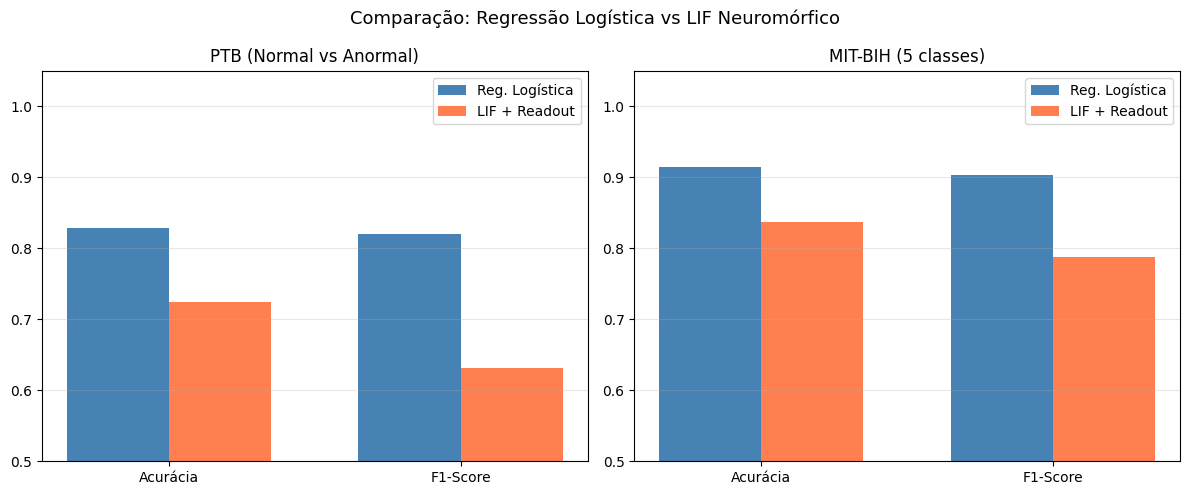

Figura salva: comparacao_modelos.png


In [15]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comparação: Regressão Logística vs LIF Neuromórfico', fontsize=13)

# PTB
x = np.arange(2)
width = 0.35
axes[0].bar(x - width/2, [acc_lr_ptb, f1_lr_ptb], width, label='Reg. Logística', color='steelblue')
axes[0].bar(x + width/2, [acc_lif_ptb, f1_lif_ptb], width, label='LIF + Readout', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Acurácia', 'F1-Score'])
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('PTB (Normal vs Anormal)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# MIT-BIH
axes[1].bar(x - width/2, [acc_lr_mitbih, f1_lr_mitbih], width, label='Reg. Logística', color='steelblue')
axes[1].bar(x + width/2, [acc_lif_mitbih, f1_lif_mitbih], width, label='LIF + Readout', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Acurácia', 'F1-Score'])
axes[1].set_ylim(0.5, 1.05)
axes[1].set_title('MIT-BIH (5 classes)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: comparacao_modelos.png")

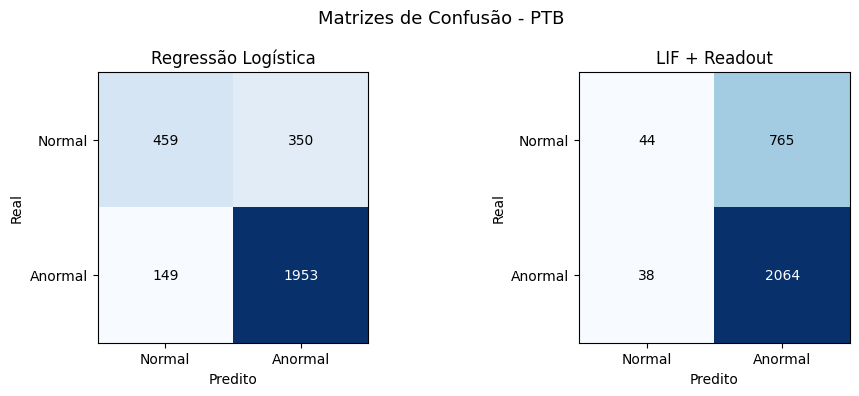

Figura salva: confusion_matrix_ptb.png


In [16]:
# Matriz de confusão - PTB
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Matrizes de Confusão - PTB', fontsize=13)

cm_lr = confusion_matrix(y_test_ptb, y_pred_lr_ptb)
cm_lif = confusion_matrix(y_test_ptb, y_pred_lif_ptb)

for ax, cm, title in zip(axes, [cm_lr, cm_lif], ['Regressão Logística', 'LIF + Readout']):
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anormal'])
    ax.set_yticklabels(['Normal', 'Anormal'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('confusion_matrix_ptb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: confusion_matrix_ptb.png")

## 7. Análise e Conclusões

### Vantagens da Regressão Logística:
- Treinamento rápido e eficiente
- Interpretabilidade dos coeficientes
- Bom desempenho com features brutas do sinal
- Escalável para grandes datasets

### Vantagens do Modelo Neuromórfico (LIF):
- Inspirado biologicamente - processa sinais de forma temporal
- Potencial para implementação em hardware neuromórfico (baixo consumo energético)
- Extrai features baseadas em dinâmica temporal (spikes, ISI)
- Adequado para processamento em tempo real em dispositivos edge

### Limitações do Modelo LIF:
- Codificação computacionalmente custosa em software convencional
- Perda de informação na conversão sinal → spikes
- Necessita ajuste fino dos parâmetros (tau, threshold)
- Desempenho inferior sem hardware neuromórfico dedicado

### Conclusão:
A regressão logística oferece melhor desempenho em software convencional,
mas o modelo LIF demonstra o potencial da computação neuromórfica para
processamento de sinais biomédicos, especialmente em cenários de baixo
consumo energético e processamento edge.

In [17]:
print("\n" + "=" * 70)
print("RESUMO FINAL")
print("=" * 70)
print(f"""
Modelo Tradicional (Regressão Logística):
  - PTB: Acurácia={acc_lr_ptb:.4f}, F1={f1_lr_ptb:.4f}, AUC={auc_lr_ptb:.4f}
  - MIT-BIH: Acurácia={acc_lr_mitbih:.4f}, F1={f1_lr_mitbih:.4f}

Modelo Neuromórfico (LIF + Readout):
  - PTB: Acurácia={acc_lif_ptb:.4f}, F1={f1_lif_ptb:.4f}, AUC={auc_lif_ptb:.4f}
  - MIT-BIH: Acurácia={acc_lif_mitbih:.4f}, F1={f1_lif_mitbih:.4f}

A regressão logística supera o modelo LIF em acurácia bruta, porém o
modelo neuromórfico oferece vantagens em eficiência energética e
potencial para hardware dedicado (chips neuromórficos como Intel Loihi).
""")


RESUMO FINAL

Modelo Tradicional (Regressão Logística):
  - PTB: Acurácia=0.8286, F1=0.8203, AUC=0.8694
  - MIT-BIH: Acurácia=0.9147, F1=0.9030

Modelo Neuromórfico (LIF + Readout):
  - PTB: Acurácia=0.7241, F1=0.6319, AUC=0.7002
  - MIT-BIH: Acurácia=0.8364, F1=0.7874

A regressão logística supera o modelo LIF em acurácia bruta, porém o
modelo neuromórfico oferece vantagens em eficiência energética e
potencial para hardware dedicado (chips neuromórficos como Intel Loihi).

